In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import seaborn as sns
df = sns.load_dataset('titanic')

print(df.head(10))
print("\nShape:", df.shape)

print("\nTarget Variable: survived")

   survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0         0       3    male  22.0      1      0   7.2500        S   Third   
1         1       1  female  38.0      1      0  71.2833        C   First   
2         1       3  female  26.0      0      0   7.9250        S   Third   
3         1       1  female  35.0      1      0  53.1000        S   First   
4         0       3    male  35.0      0      0   8.0500        S   Third   
5         0       3    male   NaN      0      0   8.4583        Q   Third   
6         0       1    male  54.0      0      0  51.8625        S   First   
7         0       3    male   2.0      3      1  21.0750        S   Third   
8         1       3  female  27.0      0      2  11.1333        S   Third   
9         1       2  female  14.0      1      0  30.0708        C  Second   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes

In [3]:
df['age'].fillna(df['age'].mean(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

df = df[['survived','pclass','sex','age','sibsp','parch','fare','embarked']]

df['sex'] = df['sex'].map({'male':0, 'female':1})
df = pd.get_dummies(df, columns=['embarked'], drop_first=True)

print(df.head())

   survived  pclass  sex   age  sibsp  parch     fare  embarked_Q  embarked_S
0         0       3    0  22.0      1      0   7.2500       False        True
1         1       1    1  38.0      1      0  71.2833       False       False
2         1       3    1  26.0      0      0   7.9250       False        True
3         1       1    1  35.0      1      0  53.1000       False        True
4         0       3    0  35.0      0      0   8.0500       False        True


/tmp/ipykernel_13398/155464903.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(), inplace=True)
/tmp/ipykernel_13398/155464903.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [5]:
df['age'].fillna(df['age'].mean(), inplace=True)

df = df[['survived','pclass','sex','age','sibsp','parch','fare', 'embarked_Q', 'embarked_S']]

print(df.head())

   survived  pclass  sex   age  sibsp  parch     fare  embarked_Q  embarked_S
0         0       3    0  22.0      1      0   7.2500       False        True
1         1       1    1  38.0      1      0  71.2833       False       False
2         1       3    1  26.0      0      0   7.9250       False        True
3         1       1    1  35.0      1      0  53.1000       False        True
4         0       3    0  35.0      0      0   8.0500       False        True


/tmp/ipykernel_13398/1759725138.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].mean(), inplace=True)


In [6]:
X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [7]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

print("Tree Depth:", dt.get_depth())
print("Number of Nodes:", dt.tree_.node_count)

Tree Depth: 21
Number of Nodes: 355


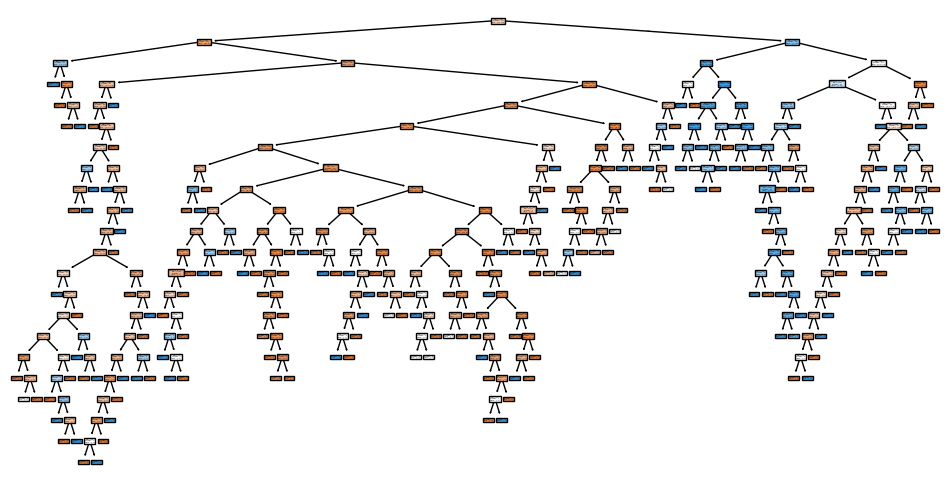

In [8]:
plt.figure(figsize=(12,6))
plot_tree(dt, feature_names=X.columns, filled=True)
plt.show()

In [9]:
dt_pruned = DecisionTreeClassifier(max_depth=3)
dt_pruned.fit(X_train, y_train)

y_pred_full = dt.predict(X_test)
y_pred_pruned = dt_pruned.predict(X_test)

print("Full Tree Accuracy:", accuracy_score(y_test, y_pred_full))
print("Pruned Tree Accuracy:", accuracy_score(y_test, y_pred_pruned))

Full Tree Accuracy: 0.7877094972067039
Pruned Tree Accuracy: 0.7988826815642458


In [10]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.7988826815642458


      Feature  Importance
5        fare    0.274741
1         sex    0.267292
2         age    0.257364
0      pclass    0.081844
3       sibsp    0.049508
4       parch    0.036808
7  embarked_S    0.023909
6  embarked_Q    0.008536


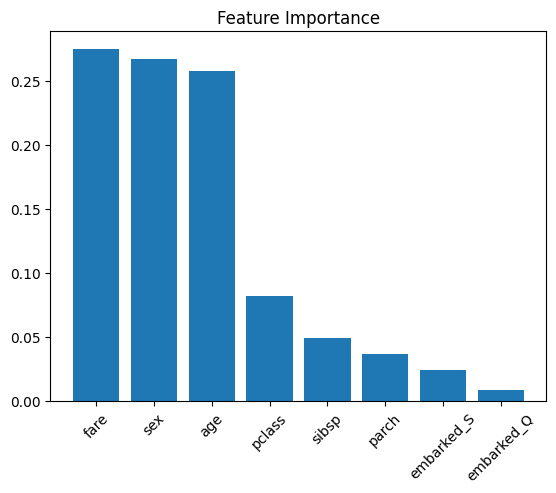

In [11]:
importances = rf.feature_importances_

feat_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_df)

plt.bar(feat_df["Feature"], feat_df["Importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

In [12]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:\n",
      classification_report(y_test, y_pred_rf))

Accuracy: 0.7988826815642458

Confusion Matrix:
 [[89 16]
 [20 54]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



In [13]:
# Conclusion:
# Decision Tree is simple and easy to interpret but can overfit the data.
# Pruning (limiting depth) helps reduce overfitting and improves generalization.
# Random Forest performs better by combining multiple trees,
# reducing variance and increasing accuracy.
# Overall, Random Forest is more robust, while Decision Tree is useful for understanding decisions.